# Hari 15 — Konsep Dasar Machine Learning

**Kickoff Minggu 3 (Modeling).** Sebelum mulai bangun model sungguhan di Hari 16-17, hari ini fokus ke tiga konsep fondasi: **supervised vs unsupervised**, **klasifikasi vs regresi**, dan **overfitting vs underfitting** — plus demo langsung pakai data proyekmu sendiri.

**Patokan yang harus diingat:** baseline naive forecast MAE = **12.953 kasus/minggu**. Semua model yang kamu buat mulai besok harus dibandingkan ke angka ini.

## Supervised vs Unsupervised Learning

| | Supervised | Unsupervised |
|---|---|---|
| Data | Ada label/target yang diketahui | Tidak ada label, cuma fitur |
| Tujuan | Memprediksi target untuk data baru | Menemukan pola/struktur tersembunyi |
| Contoh | Prediksi harga rumah, prediksi kasus COVID minggu depan | Mengelompokkan pelanggan jadi beberapa segmen |

**Proyekmu:** supervised — kamu punya `target_minggu_depan` yang jelas sebagai jawaban benar untuk setiap baris training.

## Klasifikasi vs Regresi

Dua jenis supervised learning dibedakan dari **bentuk target**-nya:

- **Klasifikasi** → target berupa kategori/kelas (survived/tidak, spam/bukan, jenis bunga apa)
- **Regresi** → target berupa angka kontinu (harga, suhu, jumlah kasus)

**Proyekmu masuk kategori REGRESI** — target-nya `target_minggu_depan` adalah angka (jumlah kasus), bukan kategori. Ini penting karena menentukan pilihan algoritma dan metrik evaluasi: Linear Regression/Random Forest **Regressor** (bukan Classifier), dievaluasi pakai MAE/RMSE (bukan accuracy/precision/recall seperti klasifikasi).

## Latihan: Identifikasi Jenis Masalah ML

Untuk tiap studi kasus di bawah, tentukan: **Klasifikasi**, **Regresi**, atau **Unsupervised**. Isi jawabanmu di titik-titik:

> 1. Memprediksi apakah sebuah email itu spam atau bukan → **Klasifikasi**
> 2. Memprediksi harga rumah berdasarkan luas, lokasi, jumlah kamar → **Regresi**
> 3. Mengelompokkan pelanggan toko online jadi beberapa segmen berdasarkan pola belanja, tanpa tahu segmen "benar"-nya apa sebelumnya → **Unsupervised**
> 4. Memprediksi suhu besok berdasarkan data cuaca beberapa hari terakhir → **Regresi**
> 5. Menentukan apakah gambar berisi kucing, anjing, atau burung → **Klasifikasi**
> 6. **(Proyekmu)** Memprediksi jumlah kasus COVID-19 minggu depan berdasarkan kasus minggu-minggu sebelumnya → **Regresi**

## Overfitting vs Underfitting

- **Underfitting**: model terlalu sederhana, bahkan gagal menangkap pola di data training sendiri. Ciri: error tinggi di train MAUPUN test.
- **Overfitting**: model terlalu kompleks, "menghafal" data training sampai ke detail/noise-nya. Ciri: error SANGAT rendah di train, tapi tinggi di test — model gagal generalisasi ke data baru.
- **Pas (good fit)**: model cukup kompleks untuk menangkap pola asli, tapi tidak ikut menghafal noise. Error train dan test sama-sama rendah dan tidak jauh berbeda.

Daripada cuma dihafal, mari lihat langsung pakai data proyekmu sendiri.

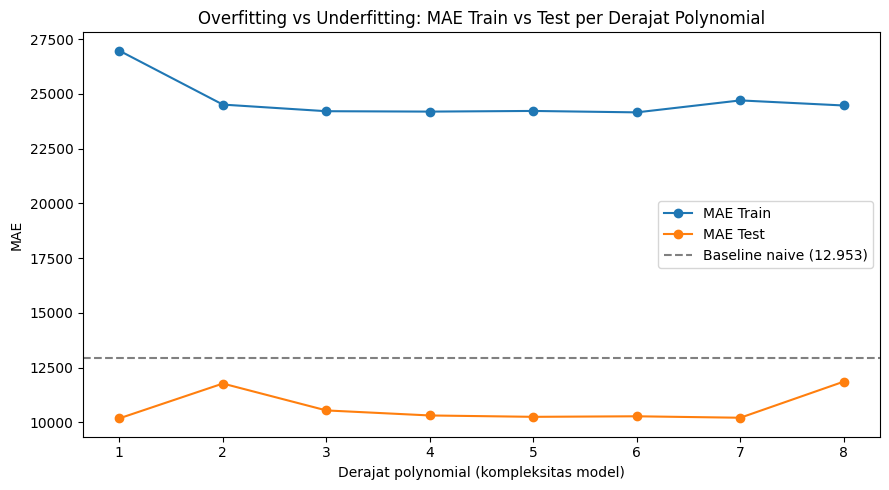

Derajat 1: MAE Train = 26,966 | MAE Test = 10,182
Derajat 2: MAE Train = 24,506 | MAE Test = 11,771
Derajat 3: MAE Train = 24,204 | MAE Test = 10,543
Derajat 4: MAE Train = 24,186 | MAE Test = 10,313
Derajat 5: MAE Train = 24,216 | MAE Test = 10,251
Derajat 6: MAE Train = 24,151 | MAE Test = 10,275
Derajat 7: MAE Train = 24,697 | MAE Test = 10,209
Derajat 8: MAE Train = 24,465 | MAE Test = 11,858


In [2]:
# Cell ini sudah lengkap — demo overfitting/underfitting pakai data proyekmu sendiri.
# Kita coba fit Polynomial Regression dengan derajat berbeda-beda, HANYA pakai 1 fitur
# (lag_1) supaya bisa divisualisasikan dengan mudah dalam 2 dimensi.

import pandas as pd
#import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error

X_train_scaled = pd.read_csv("X_train_scaled.csv", index_col=0, parse_dates=True)
X_test_scaled = pd.read_csv("X_test_scaled.csv", index_col=0, parse_dates=True)
y_train = pd.read_csv("y_train.csv", index_col=0, parse_dates=True).iloc[:, 0]
y_test = pd.read_csv("y_test.csv", index_col=0, parse_dates=True).iloc[:, 0]

X_train_1fitur = X_train_scaled[["lag_1"]]
X_test_1fitur = X_test_scaled[["lag_1"]]

derajat_list = range(1, 9)
mae_train_list = []
mae_test_list = []

for derajat in derajat_list:
    model = make_pipeline(PolynomialFeatures(degree=derajat), LinearRegression())
    model.fit(X_train_1fitur, y_train)

    pred_train = model.predict(X_train_1fitur)
    pred_test = model.predict(X_test_1fitur)

    mae_train_list.append(mean_absolute_error(y_train, pred_train))
    mae_test_list.append(mean_absolute_error(y_test, pred_test))

plt.figure(figsize=(9, 5))
plt.plot(derajat_list, mae_train_list, marker="o", label="MAE Train")
plt.plot(derajat_list, mae_test_list, marker="o", label="MAE Test")
plt.axhline(12953, color="gray", linestyle="--", label="Baseline naive (12.953)")
plt.xlabel("Derajat polynomial (kompleksitas model)")
plt.ylabel("MAE")
plt.title("Overfitting vs Underfitting: MAE Train vs Test per Derajat Polynomial")
plt.legend()
plt.tight_layout()
plt.show()

for d, tr, te in zip(derajat_list, mae_train_list, mae_test_list):
    print(f"Derajat {d}: MAE Train = {tr:,.0f} | MAE Test = {te:,.0f}")

## Membaca Grafik di Atas

Pola yang biasanya muncul:
- **Derajat rendah (1-2)**: MAE train masih tinggi → model terlalu sederhana untuk menangkap pola (kandidat underfitting)
- **Derajat menengah**: MAE train dan test sama-sama turun dan berdekatan → kandidat good fit
- **Derajat tinggi (7-8)**: MAE train terus turun (bahkan bisa mendekati 0), tapi MAE test malah **naik lagi** → model mulai menghafal noise di training, gagal generalisasi (overfitting)

Ingat: ini baru pakai **satu fitur** (`lag_1`) sebagai ilustrasi konsep. Model sungguhan di Hari 16-17 akan pakai semua fitur sekaligus (`lag_1`, `lag_2`, `lag_3`, `rolling_mean_4w`, `vaksin_persen`, `bulan_*`).

## Refleksi Hari 15

Lihat hasil angka MAE Train/Test dari grafik kamu sendiri di atas, lalu jawab:

> 1. Derajat berapa yang menurutmu paling menunjukkan tanda-tanda **overfitting** (MAE train sangat rendah, MAE test tinggi/naik)? → **tidak ada**
> 2. Apakah ada derajat yang MAE test-nya berhasil **mengalahkan baseline** (di bawah 12.953)? Kalau ada, derajat berapa? → **Ada, semua derajat kecuali 7 & 8**
> 3. Berdasarkan pola di atas, kenapa "model paling kompleks" tidak selalu "model paling bagus"? Jelaskan dengan bahasamu sendiri → **karena semakin kompleks model tersebut maka semakin banyak data yang dihafal sampai ke detail/noisenya oleh model tersebut**

---
### Selanjutnya: Hari 16 — Linear Regression (Model Pertama, Semua Fitur)

Besok kita bangun model sungguhan pertama: Linear Regression memakai **semua fitur** (`X_train_scaled`, bukan cuma `lag_1`), lalu evaluasi MAE-nya di test set dan bandingkan langsung ke baseline 12.953. Ini jadi model pembanding pertama sebelum coba Random Forest di Hari 17.